# Chapter 2 Exercises

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.sampling_bars import dollar_bar

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

spx = pd.read_csv('../data/raw/spx.csv')
eurostoxx = pd.read_csv('../data/raw/eurostoxx.csv')
eur_usd = pd.read_csv('../data/raw/eur_usd.csv', usecols = ['Date', 'Price'])

# rename columns to universal format
spx.rename(columns = {'Date': 'date', 'Price': 'close', 'Open': 'open', 'Vol.': 'vol'}, inplace=True) 
eurostoxx.rename(columns = {'Date': 'date', 'Price': 'close', 'Open': 'open', 'Vol.': 'vol'}, inplace=True)
eur_usd.rename(columns = {'Date': 'date', 'Price': 'close'}, inplace=True)

spx['date'] = pd.to_datetime(spx.date) #convert date column to datetime format
eurostoxx['date'] = pd.to_datetime(eurostoxx.date)
eur_usd['date'] = pd.to_datetime(eur_usd.date)

# convert price data from strings to float (investing.com uses specific decimal sep format)
spx.close = spx.close.apply(lambda x: x.replace(',', '')).astype(float)
eurostoxx.close = eurostoxx.close.apply(lambda x: x.replace(',', '')).astype(float)
spx.open = spx.open.apply(lambda x: x.replace(',', '')).astype(float)
eurostoxx.open = eurostoxx.open.apply(lambda x: x.replace(',', '')).astype(float)

def extract_mult(s) -> int:
    """Extract numeric value from string with 'K', 'M', 'B', or 'T' and return as integer."""
    if isinstance(s, (int, float)):
        return int(s)
    if isinstance(s, str):
        s = s.strip()
        mult = 1
        if s.endswith("K"):
            mult = 1e3
            s = s[:-1]
        elif s.endswith("M"):
            mult = 1e6
            s = s[:-1]
        elif s.endswith("B"):
            mult = 1e9
            s = s[:-1]
        elif s.endswith("T"):
            mult = 1e12
            s = s[:-1]
        try:
            return int(float(s.replace(",", "")) * mult)
        except ValueError:
            return 0
    return 0

spx.vol = spx.vol.apply(extract_mult)
eurostoxx.vol = eurostoxx.vol.apply(extract_mult)

spx.set_index('date', inplace=True)
eurostoxx.set_index('date', inplace=True)
eur_usd.set_index('date', inplace=True)

spx.sort_index(inplace=True)
eurostoxx.sort_index(inplace=True)
eur_usd.sort_index(inplace=True)

eur_usd = eur_usd[eur_usd.index.isin(spx.index)] # exchange rate is needed only for dates when futures are traded

In [2]:
spx.head()

,close,open,High,Low,vol,Change %
date,,,,,,
2016-03-08,1981.00,1999.00,"2,000.25","1,976.00",1930000,-0.90%
2016-03-09,1989.00,1981.75,"1,994.00","1,978.00",1740000,0.40%
2016-03-10,1988.75,1990.00,"2,010.25","1,967.25",2740000,-0.01%
2016-03-11,2020.00,1988.50,"2,022.25","1,987.50",1220000,1.57%
2016-03-14,2018.75,2019.25,"2,024.50","2,012.00",880360,-0.06%


In [3]:
DICTIO = {'Instrument':'date', 'Close':'close', 'Open':'open', 'Returns':'returns', 'rPrices':'rPrices', 'Volume':'vol'}

def getRolledSeries(series, dictio=DICTIO):
    gaps = rollGaps(series, dictio)
    for field in [dictio.get('Close', None), dictio.get('VWAP', None)]:
        if field is None:
            continue
        if field in series.columns:
            series[field] -= gaps
        else:
            print(f"[WARNING] Field {field} not found in series")
    return series


def rollGaps(series, dictio, matchEnd=True):
    # Compute gaps at each roll, between previous close and next open
    target_series = series.copy(deep=True)
    rollDates = target_series.index
    gaps = target_series[dictio['Close']] * 0
    iloc = list(target_series.index)
    iloc = [iloc.index(i) - 1 for i in rollDates] # index of days prior to roll
    gaps.loc[rollDates[1:]] = target_series[dictio['Open']].loc[rollDates[1:]] - target_series[dictio['Close']].iloc[iloc[1:]].values
    gaps = gaps.cumsum()
    if matchEnd:
        gaps -= gaps.iloc[-1]
    return gaps

def non_negative_series(series, dictio=DICTIO):
    target_series = series.copy(deep=True)
    target_series[dictio['Returns']] = target_series[dictio['Close']].diff() / target_series[dictio['Close']].shift(1)
    target_series[dictio['rPrices']] = (1 + target_series[dictio['Returns']]).cumprod()
    return target_series

## 3. On dollar bar series of E-mini S&P 500 futures and Eurostoxx 50 futures:

### a. Apply Section 2.4.2 (PCA Weights) to compute the vector $\{\hat{\omega_t}\}$ used by the ETF trick. (Hint: You will need FX values for EUR/USD at the roll dates.)

In [4]:
rolled_spx = getRolledSeries(spx)
spx_bars = non_negative_series(rolled_spx)

rolled_eurostoxx = getRolledSeries(eurostoxx)
eurostoxx_bars = non_negative_series(eurostoxx)

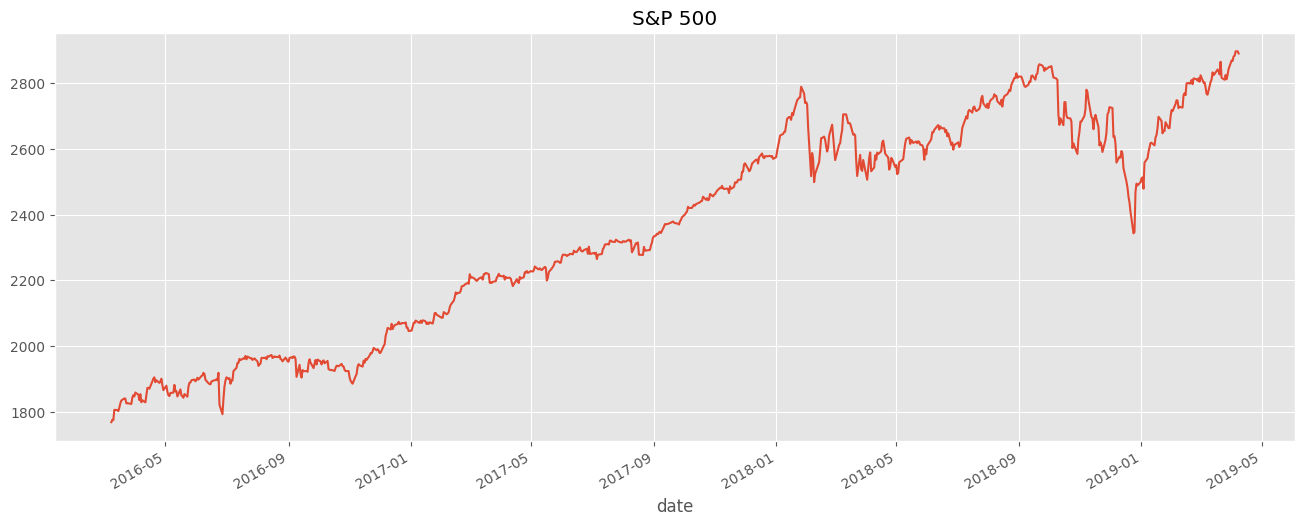

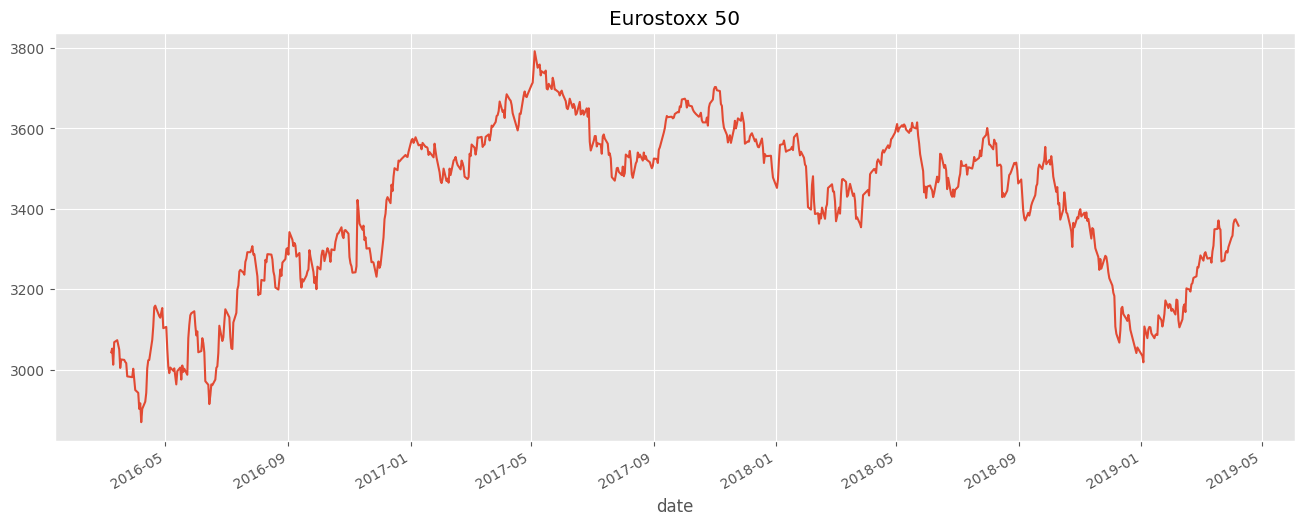

In [5]:
fig = plt.figure()
spx_bars['close'].plot()
plt.title('S&P 500')
plt.show()

fig = plt.figure()
eurostoxx_bars['close'].plot()
plt.title('Eurostoxx 50')
plt.show()

In [6]:
def pca_weights(cov, risk_dist=None, risk_target=1.):
    # Compute PCA weights for dollar bars
    eigen_vals, eigen_vecs = np.linalg.eigh(cov)
    eigen_sorted_indices = np.argsort(eigen_vals)[::-1]
    # sort the eigenvalues and eigenvectors in descending order of eigenvalues
    eigen_vals = eigen_vals[eigen_sorted_indices]
    eigen_vecs = eigen_vecs[:, eigen_sorted_indices]
    
    if risk_dist is None:
        risk_dist = np.zeros(len(eigen_vals))
        risk_dist[-1] = 1. # we assign all the risks to the lowest eigenvalue

    beta = risk_target * (risk_dist / eigen_vals) ** 0.5    
    weights = eigen_vecs @ beta.reshape(-1, 1)
    
    return weights

In [7]:
# Get the covariance matrix of the dollar bars

target_bars = 100
spx['dollar_vol'] = spx['close'] * spx['vol']
dollar_size = spx["dollar_vol"].sum() / target_bars
spx_dollar_bars = dollar_bar(spx, dollar_size=dollar_size)
print(f"Shape of SPX dollar bar: {spx_dollar_bars.shape}")
print(f"Comparing the original bar shape: {spx_bars.shape}")
print(f"And Comparing the raw data shape: {spx.shape}")

print()

eurostoxx['dollar_vol'] = eurostoxx['close'] * eurostoxx['vol']
dollar_size = eurostoxx["dollar_vol"].sum() / target_bars
eurostoxx_dollar_bars = dollar_bar(eurostoxx, dollar_size=dollar_size)
print(f"Shape of Eurostoxx dollar bar: {eurostoxx_dollar_bars.shape}")
print(f"Comparing the original bar shape: {eurostoxx_bars.shape}")
print(f"And Comparing the raw data shape: {eurostoxx.shape}")

Shape of SPX dollar bar: (93, 7)
Comparing the original bar shape: (816, 8)
And Comparing the raw data shape: (816, 7)

Shape of Eurostoxx dollar bar: (92, 7)
Comparing the original bar shape: (788, 8)
And Comparing the raw data shape: (788, 7)


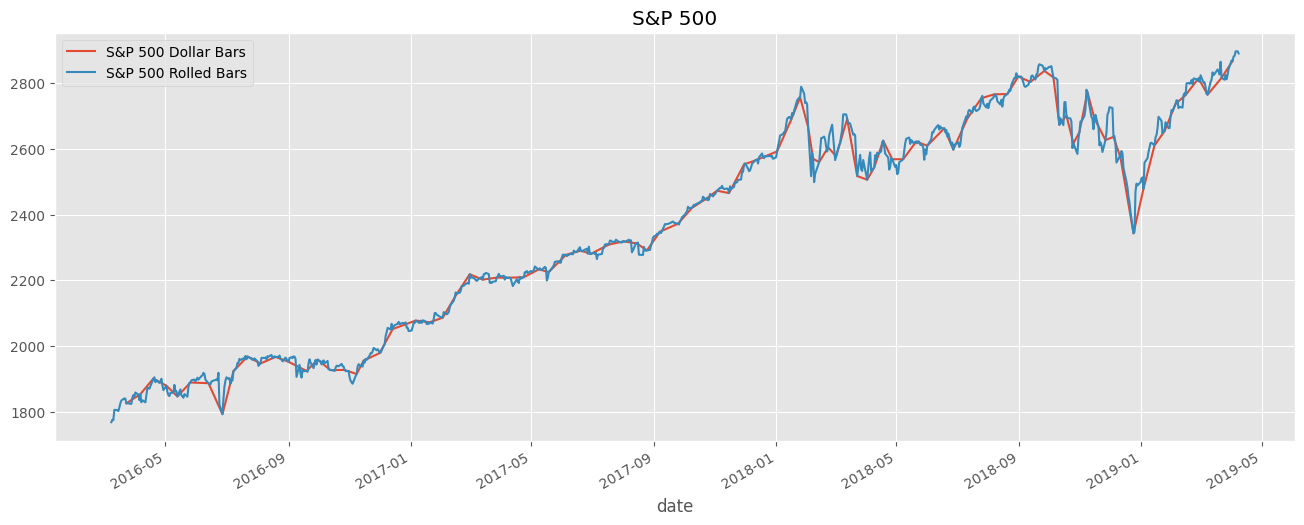

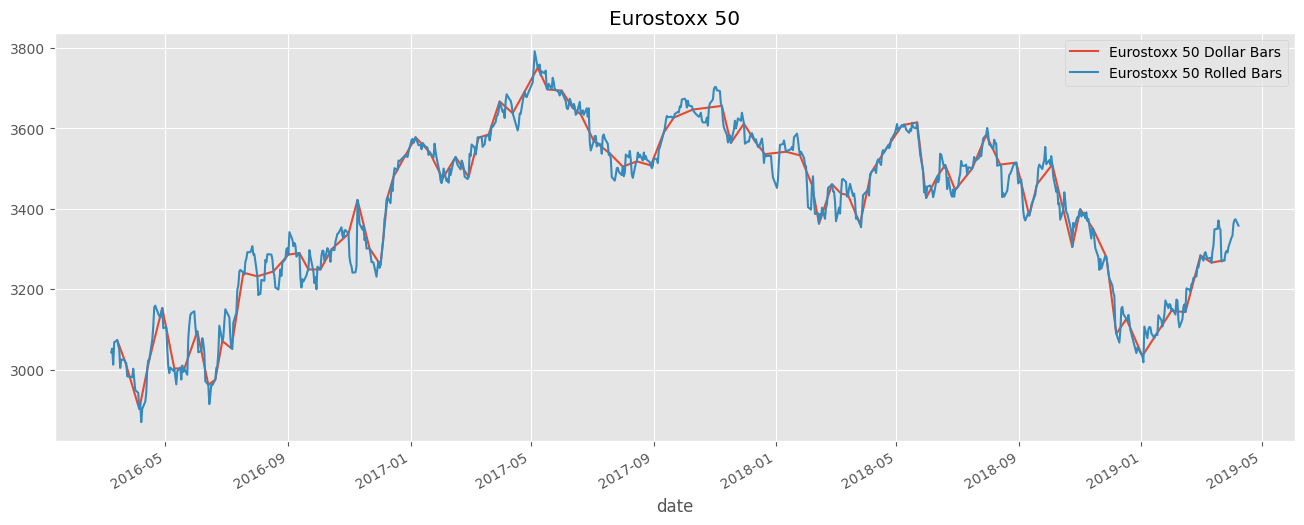

In [8]:
# plot the dollar bars
fig = plt.figure()
spx_dollar_bars['close'].plot(label="S&P 500 Dollar Bars")
spx_bars['close'].plot(label="S&P 500 Rolled Bars")
plt.legend()
plt.title('S&P 500')
plt.show()

fig = plt.figure()
eurostoxx_dollar_bars['close'].plot(label="Eurostoxx 50 Dollar Bars")
eurostoxx_bars['close'].plot(label="Eurostoxx 50 Rolled Bars")
plt.legend()
plt.title('Eurostoxx 50')
plt.show()

In [13]:
prices = pd.concat({'EUR_STX': eurostoxx_dollar_bars['close'], 'SPX': spx_dollar_bars['close']}, axis=1)
prices = prices.ffill()

# Generate random FX data for EURUSD
prices['EURUSD'] = eur_usd
prices['STX_USD'] = prices['EUR_STX'] * prices['EURUSD']

prices = prices[["SPX", "STX_USD"]].dropna()
returns = prices.pct_change().dropna()

lookback = 100
omega_t = {}
for t in range(lookback, len(returns)):
    cov_t = returns.iloc[t - lookback:t].cov()
    omega_t[returns.index[t]] = pca_weights(cov_t).ravel()

omega_t = pd.DataFrame.from_dict(
    omega_t,
    orient="index",
    columns=returns.columns,
)

omega_t = omega_t.div(omega_t.abs().sum(axis=1), axis=0)

/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_13543/882056797.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  prices = pd.concat({'EUR_STX': eurostoxx_dollar_bars['close'], 'SPX': spx_dollar_bars['close']}, axis=1)


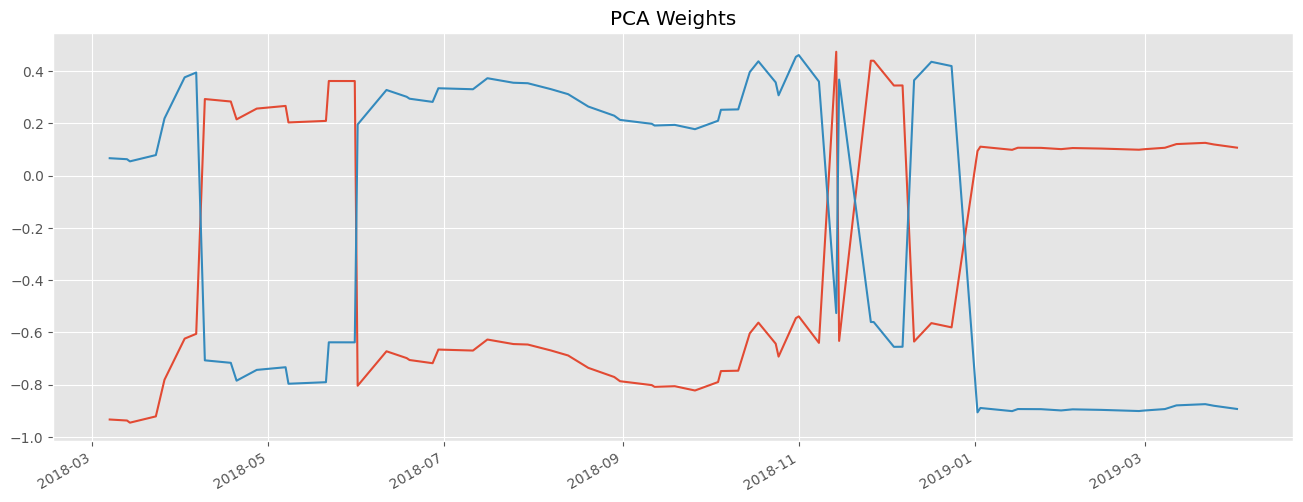

In [14]:
# plot the weights
fig = plt.figure()
omega_t.plot(ax=fig.gca(), legend=False)
plt.title('PCA Weights')
plt.show()

### b. Derive the time series of the S&P 500/Eurostoxx 50 spread.

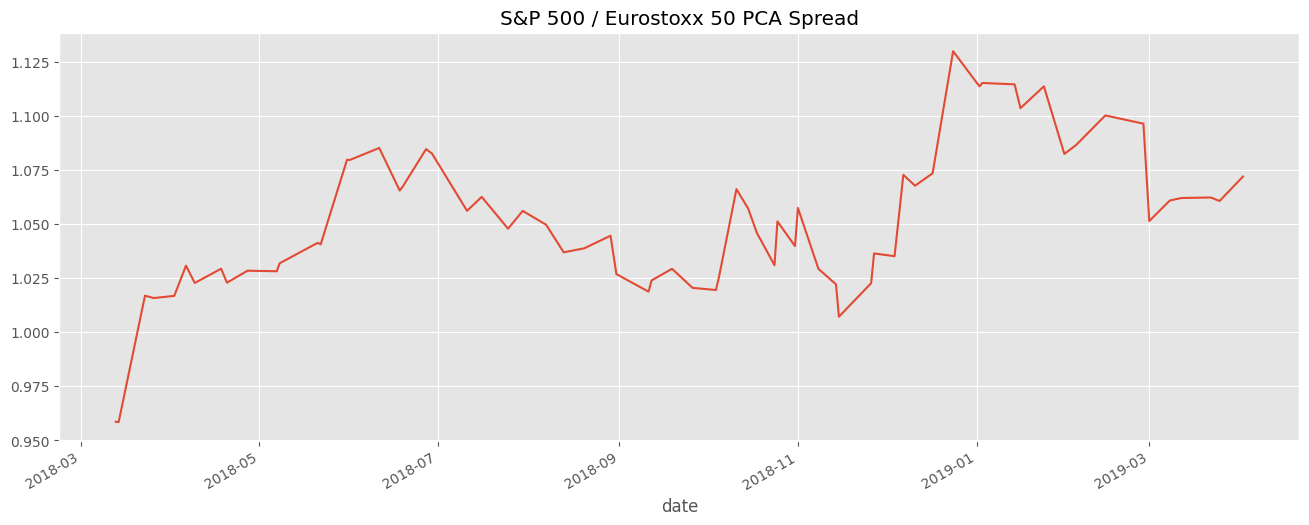

In [16]:
weights = omega_t.shift(1).reindex(returns.index)
spread_returns = (weights * returns).sum(axis=1, min_count=2).dropna()

spread = (1 + spread_returns).cumprod()
spread.name = "SPX_STX_spread"

spread.plot(title="S&P 500 / Eurostoxx 50 PCA Spread")
plt.show()

### c. Confirm that the series is stationary, with an ADF test.

In [17]:
# Run the ADF test
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(spread)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -3.1933991227063125
p-value: 0.02036995740228523
Critical Values: {'1%': np.float64(-3.5319549603840894), '5%': np.float64(-2.905755128523123), '10%': np.float64(-2.5903569458676765)}
